# Noisy-channel Bayesian artifact explorer

This notebook reads the completed Qwen3.5-9B JSONL generated by notebook 13 and never changes it. It creates three in-memory SQLite tables:

- transcript_rows: all 1,600 presentation-level records, including candidate order, logits, completions, likelihood factors, posteriors, and evidence.
- balanced_rows: 800 rows after matching C1-first with C2-first.
- reasoning_pairs: 400 rows after additionally matching reasoning off with reasoning on.

The semantic answer-surface contrast used throughout is

\[
z = \operatorname{logit}(C_1)-\operatorname{logit}(C_2),
\qquad
z_{\mathrm{balanced}} = \frac{z_{\mathrm{C1-first}}+z_{\mathrm{C2-first}}}{2}.
\]

All derived databases are in memory. The source JSONL is opened with mode r, and this notebook has no generation or artifact-writing step.

In [1]:
from __future__ import annotations

import math
import random
import sys
from collections import Counter, defaultdict
from pathlib import Path
from pprint import pprint
from statistics import fmean, median

import matplotlib.pyplot as plt
from IPython.display import display

REPO_ROOT = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").exists()
)
sys.path.insert(0, str(REPO_ROOT / "notebooks"))

from noisy_channel_artifact_explorer import SQLResult, load_explorer

explorer = load_explorer()
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 115, "axes.spines.top": False, "axes.spines.right": False})

explorer.summary()

{'source': '/workspace/MATS/artifacts/noisy_channel_bayesian_experiment_2/Qwen_Qwen3.5-9B_4c87a623/runs/agreement_logits_reliability_sweep_generated_answer_line_v1_transformers/results.jsonl',
 'artifact_mode': 'read-only source; in-memory SQLite derivatives',
 'transcript_rows': 1600,
 'balanced_rows': 800,
 'reasoning_pairs': 400,
 'models': ['Qwen/Qwen3.5-9B'],
 'reliabilities': ['0/1', '1/1', '1/10', '1/2', '9/10'],
 'missing_answer_boundary_logits': 3}

## Column model and query semantics

Controlled columns include question_set_index, answer_pattern, reliability, reasoning, and presentation_order. Candidate order is represented both as presentation_order and the C1-first/C2-first flags.

Derived columns include per-question agreement and likelihood factors, likelihood totals, exact and floating candidate posteriors, a strict log-posterior contrast (undefined for 0/0), and total_marginalized_probability (the prior-predictive probability of the observation pattern). The logit columns are read from answer_surface_raw_logits, which was produced via the CaptureSpec used in notebook 13.

Use explorer.sql(...) for actual SQLite, or the immutable Python builder shown below. SQL uses 0/1 for booleans and ? placeholders for parameters.

In [2]:
# Table sizes and schemas are queryable too.
display(explorer.sql("""
SELECT 'transcript_rows' AS table_name, COUNT(*) AS n FROM transcript_rows
UNION ALL
SELECT 'balanced_rows', COUNT(*) FROM balanced_rows
UNION ALL
SELECT 'reasoning_pairs', COUNT(*) FROM reasoning_pairs
"""))

# Uncomment any of these when you want the full column inventory.
# display(explorer.columns("transcript_rows"))
# display(explorer.columns("balanced_rows"))
# display(explorer.columns("reasoning_pairs"))

table_name,n
transcript_rows,1600
balanced_rows,800
reasoning_pairs,400


In [3]:
# Pythonic SELECT / WHERE / GROUP BY / HAVING / SORT / COUNT.
grouped_query = (
    explorer.query("transcript_rows")
    .select(
        "reliability_exact",
        "reasoning",
        "COUNT(*) AS n",
        "AVG(z) AS mean_z",
        "AVG(reasoning_length_tokens) AS mean_reasoning_tokens",
    )
    .where("answer_boundary_available = ?", 1)
    .group_by("reliability_exact", "reasoning")
    .having("COUNT(*) >= ?", 10)
    .sort("reliability", "reasoning")
)
print(grouped_query.sql_text())
display(grouped_query.run())

n_reasoning_on_at_r09 = (
    explorer.query("transcript_rows")
    .where_eq(reasoning=True, reliability_exact="9/10")
    .count()
)
print("COUNT reasoning-on presentation rows at r=0.9:", n_reasoning_on_at_r09)

SELECT reliability_exact, reasoning, COUNT(*) AS n, AVG(z) AS mean_z, AVG(reasoning_length_tokens) AS mean_reasoning_tokens FROM "transcript_rows"
WHERE (answer_boundary_available = ?)
GROUP BY reliability_exact, reasoning
HAVING (COUNT(*) >= ?)
ORDER BY reliability, reasoning


reliability_exact,reasoning,n,mean_z,mean_reasoning_tokens
0/1,0,160,-0.36328125,None
0/1,1,157,-0.012738853503184714,1095.4331210191083
1/10,0,160,-0.39140625,None
1/10,1,160,-0.253125,682.3875
1/2,0,160,-0.39921875,None
1/2,1,160,0.35078125,705.20625
9/10,0,160,-0.428125,None
9/10,1,160,-0.22265625,633.15
1/1,0,160,-0.3453125,None
1/1,1,160,0.13203125,578.75


COUNT reasoning-on presentation rows at r=0.9: 160


In [4]:
# The same style of exploration in direct SQL.
display(explorer.sql("""
SELECT
    question_set_index,
    answer_pattern,
    reliability_exact,
    reasoning,
    presentation_order,
    total_agreement_candidate_1,
    total_agreement_candidate_2,
    candidate_1_likelihood_total,
    candidate_2_likelihood_total,
    candidate_1_posterior,
    candidate_2_posterior,
    total_marginalized_probability,
    z
FROM transcript_rows
WHERE reliability_exact = ? AND reasoning = ?
ORDER BY ABS(z) DESC
LIMIT 12
""", ("9/10", True)))

question_set_index,answer_pattern,reliability_exact,reasoning,presentation_order,total_agreement_candidate_1,total_agreement_candidate_2,candidate_1_likelihood_total,candidate_2_likelihood_total,candidate_1_posterior,candidate_2_posterior,total_marginalized_probability,z
7,YNY,9/10,1,C1_C2,1,2,0.008999999999999996,0.08099999999999999,0.009,0.081,0.125,-14.25
0,YYN,9/10,1,C1_C2,1,2,0.008999999999999996,0.08099999999999999,0.009,0.081,0.125,-14.125
7,YYN,9/10,1,C1_C2,1,2,0.008999999999999996,0.08099999999999999,0.009,0.081,0.125,-14.0
0,NYY,9/10,1,C1_C2,1,2,0.008999999999999996,0.08099999999999999,0.009,0.081,0.125,-13.875
2,NNY,9/10,1,C1_C2,1,2,0.008999999999999996,0.08099999999999999,0.025,0.225,0.045,-13.875
3,YNN,9/10,1,C1_C2,1,2,0.008999999999999996,0.08099999999999999,0.025,0.225,0.045,-13.875
3,NYN,9/10,1,C1_C2,1,2,0.008999999999999996,0.08099999999999999,0.009,0.081,0.125,-13.875
1,YNY,9/10,1,C1_C2,0,2,0.0009999999999999994,0.08099999999999999,0.001,0.081,0.125,-13.75
2,YYY,9/10,1,C1_C2,1,2,0.008999999999999996,0.08099999999999999,0.009,0.081,0.125,-13.75
4,NNN,9/10,1,C1_C2,1,3,0.008999999999999996,0.7290000000000001,0.00548780487804878,0.4445121951219512,0.205,-13.75


### Inspecting the untouched transcript artifact

The SQL tables intentionally flatten nested JSON into scalar or JSON-text columns. Given any source row ID, raw_row returns the untouched source dictionary, including messages, generated token IDs, answer-boundary metadata, logits, and full completion.

In [5]:
def inspect_transcript(row_id: str, *, include_prompt: bool = False) -> dict:
    raw = explorer.raw_row(row_id)
    selected = {
        "row_id": raw["row_id"],
        "question_set_index": raw["question_set_index"],
        "answer_pattern": raw["answer_pattern"],
        "reliabilities_exact": raw["reliabilities_exact"],
        "reasoning": raw["reasoning"],
        "presentation_order": raw["presentation_order"],
        "membership_sets": raw["membership_sets"],
        "observed_reports": raw["observed_reports"],
        "answer_surface_raw_logits": raw.get("answer_surface_raw_logits"),
        "reasoning_length_tokens": raw.get("reasoning_length_tokens"),
        "model_choice_canonical": raw.get("model_choice_canonical"),
        "canonical_posterior_correct": raw.get("canonical_posterior_correct"),
        "full_completion": raw.get("full_completion"),
    }
    if include_prompt:
        selected["messages"] = raw["messages"]
    return selected

sample_id = explorer.transcript_rows[0]["row_id"]
pprint(inspect_transcript(sample_id))

{'answer_pattern': 'YYY',
 'answer_surface_raw_logits': {'2': 22.125, '7': 22.75},
 'canonical_posterior_correct': False,
 'full_completion': 'ANSWER: 7',
 'membership_sets': [[3, 5, 6, 8], [1, 5, 7, 8], [1, 4, 5, 6]],
 'model_choice_canonical': 'C2',
 'observed_reports': ['YES', 'YES', 'YES'],
 'presentation_order': 'C1_C2',
 'question_set_index': 0,
 'reasoning': False,
 'reasoning_length_tokens': None,
 'reliabilities_exact': ['0/1', '0/1', '0/1'],
 'row_id': '9187d2536a9208aebe3c4c9a'}


## 1. Where reasoning rescued a likely incorrect answer

Correctness here is determined from the sign of the position-balanced answer-surface contrast and the exact Bayesian pair-normalized target. Exact Bayesian ties and rows where both candidate posteriors are zero are marked not scored. “Likely incorrect” is configurable below; the default requires the reasoning-off logits to put at least 75% probability on the wrong candidate.

The table retains all four source row IDs, so any off/on and C1-first/C2-first transcript can be opened with inspect_transcript(...).

$q_{true}$ : Here, every (q) is the probability assigned to semantic candidate C1 (candidate value 2), while C2 is candidate value 7.

 $ [
  q_{\text{true}}
  =\frac{p(C_1\mid D)}
  {p(C_1\mid D)+p(C_2\mid D)}
  ]$

  It is the mathematically correct Bayesian probability after normalizing over only C1 and C2. It does not change when reasoning is enabled because the evidence (D) is unchanged.

The logits: 
  $[
  z_{\text{off}}
  =\frac{z_{\text{C1-first,off}}+z_{\text{C2-first,off}}}{2},
  \qquad
  z_{\text{on}}
  =\frac{z_{\text{C1-first,on}}+z_{\text{C2-first,on}}}{2},
  ]$

  where every $(z=\operatorname{logit}(C_1)-\operatorname{logit}(C_2)).$

  Thus:

  - (z>0): model favors C1.
  - (z<0): model favors C2.
  - Larger $(|z|)$: stronger confidence.

---
The model-implied probabilities are:

 $ [
  q_{\text{LLM,off}}=\sigma(z_{\text{off}}),\qquad
  q_{\text{LLM,on}}=\sigma(z_{\text{on}}),
  ]$

  where ($\sigma(z)=1/(1+e^{-z})$). There is no separate reasoning-dependent q_true.

  For your first row:

  - ($q_{\text{true}}=0$): C1 is impossible and C2 is certain among the two candidates.
  - ($z_{\text{off}}=2.0625$), so ($q_{\text{LLM,off}}=0.8872$): without reasoning, the model assigns 88.72% to the wrong candidate C1.
  - ($z_{\text{on}}=-10.0625$), so ($q_{\text{LLM,on}}=0.00004265$): with reasoning, it assigns only 0.0043% to C1 and 99.9957% to the correct C2.


In [13]:
LIKELY_INCORRECT_THRESHOLD = 0.50

reasoning_rescues = (
    explorer.query("reasoning_pairs")
    .select(
        "question_set_index",
        "reliability_exact",
        "question_subsets_json",
        "observed_reports_json",
        "q_true",
        "z_off",
        "z_on",
        #"z_on_minus_off",
        "q_llm_off",
        "q_llm_on",
        "off_wrong_confidence",
        "delta_probability_true_choice",
        "confidence_amplification",
        "reasoning_length_tokens",
        "semantic_choice_c1_first_off",
        "semantic_choice_c1_first_on",
        "semantic_choice_c2_first_off",
        "semantic_choice_c2_first_on",
        #"off_c1_first_row_id",
        "on_c1_first_row_id",
    )
    .where("correctness_transition = ?", "wrong→right")
    .where("off_wrong_confidence >= ?", LIKELY_INCORRECT_THRESHOLD)
    .sort("off_wrong_confidence DESC", "delta_probability_true_choice DESC")
    .run()
)
print(
    f"{len(reasoning_rescues)} high-confidence reasoning rescues "
    f"at threshold {LIKELY_INCORRECT_THRESHOLD:.0%}"
)
display(reasoning_rescues)

70 high-confidence reasoning rescues at threshold 50%


question_set_index,reliability_exact,question_subsets_json,observed_reports_json,q_true,z_off,z_on,q_llm_off,q_llm_on,off_wrong_confidence,delta_probability_true_choice,confidence_amplification,reasoning_length_tokens,semantic_choice_c1_first_off,semantic_choice_c1_first_on,semantic_choice_c2_first_off,semantic_choice_c2_first_on,on_c1_first_row_id
7,0/1,"[[4,5,7,8],[5,6,7,8],[3,4,7,8]]","[""NO"",""NO"",""NO""]",0.0,2.0625,-10.0625,0.8872045937171068,4.2647468185579125e-05,0.8872045937171068,0.8871619462489212,8.0,594.5,C1,C2,C1,C2,2e87679b3d812f698a72110d
7,1/10,"[[4,5,7,8],[5,6,7,8],[3,4,7,8]]","[""NO"",""NO"",""NO""]",0.0013698630136986301,1.75,-10.6875,0.8519528019683106,2.282799719288797e-05,0.8519528019683106,0.8519299739711177,8.9375,700.5,C1,C2,C1,C2,e5752d68284f35244fa75807
7,1/10,"[[4,5,7,8],[5,6,7,8],[3,4,7,8]]","[""YES"",""YES"",""YES""]",0.9986301369863013,-1.3125,10.8125,0.21206880435710532,0.999979854309147,0.7879311956428947,0.7879110499520418,9.5,664.5,C2,C1,C2,C1,c39ca3d0dd55863d0a8ef765
1,0/1,"[[4,6,7,8],[2,4,5,8],[1,3,5,6]]","[""YES"",""NO"",""YES""]",1.0,-1.1875,10.625,0.23370635691404026,0.9999756997592568,0.7662936430859597,0.7662693428452165,9.4375,863.0,C2,C1,C2,C1,a2bd73e67956d64ab7589de3
1,1/10,"[[4,6,7,8],[2,4,5,8],[1,3,5,6]]","[""YES"",""NO"",""YES""]",0.9878048780487805,-1.1875,10.25,0.23370635691404026,0.9999646437492582,0.7662936430859597,0.7662582868352179,9.0625,676.0,C2,C1,C2,C1,c741bc6de6ab21db5eb82c9d
4,1/10,"[[1,3,4,8],[1,2,4,8],[1,2,4,5]]","[""NO"",""NO"",""NO""]",0.9878048780487805,-1.0625,10.0,0.25683199138751883,0.9999546021312976,0.7431680086124812,0.7431226107437787,8.9375,734.5,C2,C1,C2,C1,7ba47e5faf1855c23652a6ed
2,0/1,"[[1,2,3,4],[4,5,7,8],[3,4,7,8]]","[""NO"",""YES"",""YES""]",1.0,-1.0,11.0625,0.2689414213699951,0.9999843104502723,0.7310585786300049,0.7310428890802771,10.0625,895.0,C2,C1,C2,C1,aa22ea397111e7ac4fbe6b33
3,1/10,"[[1,3,4,8],[1,4,6,8],[2,3,4,5]]","[""NO"",""NO"",""NO""]",0.9,-0.9375,10.6875,0.28140560742914383,0.9999771720028072,0.7185943925708562,0.7185715645736634,9.75,734.5,C2,C1,C2,C1,25f71cc4855eb4dedd47ae6c
6,1/10,"[[2,4,7,8],[1,2,6,7],[1,5,6,7]]","[""YES"",""YES"",""YES""]",0.9,-0.9375,10.5,0.28140560742914383,0.9999724643088853,0.7185943925708562,0.7185668568797414,9.5625,655.5,C2,C1,C2,C1,07c3b2f77bc06631e93c7c1f
7,1/10,"[[4,5,7,8],[5,6,7,8],[3,4,7,8]]","[""NO"",""NO"",""YES""]",0.09999999999999999,0.875,-11.5,0.7057850278370112,1.0129990980873921e-05,0.7057850278370112,0.7057748978460304,10.625,698.0,C1,C2,C1,C2,082a7cf6463081cd2cdcfaa1


In [14]:
# Example: inspect the reasoning-on transcript for the strongest rescue.
if reasoning_rescues:
    pprint(inspect_transcript(reasoning_rescues[0]["on_c1_first_row_id"]))

{'answer_pattern': 'NNN',
 'answer_surface_raw_logits': {'2': 19.5, '7': 31.0},
 'canonical_posterior_correct': True,
 'full_completion': 'The domain for the secret integer s is {1, 2, 3, 4, 5, 6, '
                    '7, 8}. Since the prior is uniform, each value has an '
                    'initial probability of 1/8.\n'
                    '\n'
                    'The source report is perfectly inverted (r=0). This '
                    'means:\n'
                    '- If the truthful answer is YES, the source reports NO.\n'
                    '- If the truthful answer is NO, the source reports YES.\n'
                    'Therefore, a reported "NO" implies the truthful answer '
                    'was "YES". A reported "YES" implies the truthful answer '
                    'was "NO".\n'
                    '\n'
                    "Let's analyze the observations for the candidate s=2:\n"
                    'Q1: Is s in {4, 5, 7, 8}? Truthful answer for s=2 is NO. '
        

## 2. Order-specific stability

For each position pair this section records

$\[
z_{\mathrm{C1-first}},\quad z_{\mathrm{C2-first}},\quad
\Delta_{\mathrm{position}}
=\frac{z_{\mathrm{C1-first}}-z_{\mathrm{C2-first}}}{2}.
\]$

Both a logit-sign flip and a flip in the actually emitted semantic candidate are retained. Large opposite-signed values near a balanced value of zero are therefore visible rather than averaged away.

In [19]:
order_instability = (
    explorer.query("balanced_rows")
    .select(
        "question_set_index",
        "question_subsets_json",
        "answer_pattern",
        "reliability_exact",
        "q_true",
        "reasoning",
        "z_c1_first",
        "z_c2_first",
        "z_balanced",
        "delta_position",
        "absolute_order_gap",
        "logit_sign_flip_after_swap",
        "semantic_choice_c1_first",
        "semantic_choice_c2_first",
        "semantic_choice_flip_after_swap",
        "source_c1_first_row_id",
        "source_c2_first_row_id",
    )
    .where("pair_has_answer_boundary_logits = ?", 1)
   .where("q_true IS NOT NULL")
    .sort(
        "logit_sign_flip_after_swap DESC",
        "semantic_choice_flip_after_swap DESC",
        "absolute_order_gap DESC",
    )
    .limit(40)
    .run()
)
display(order_instability)

question_set_index,question_subsets_json,answer_pattern,reliability_exact,q_true,reasoning,z_c1_first,z_c2_first,z_balanced,delta_position,absolute_order_gap,logit_sign_flip_after_swap,semantic_choice_c1_first,semantic_choice_c2_first,semantic_choice_flip_after_swap,source_c1_first_row_id,source_c2_first_row_id
0,"[[3,5,6,8],[1,5,7,8],[1,4,5,6]]",NYY,1/2,0.5,1,10.375,-10.875,-0.25,10.625,21.25,1,C1,C2,1,6097d16545421fbbf29012e9,fa81b210f7cbfabdbf7f912b
9,"[[1,2,3,7],[1,3,5,6],[1,2,4,8]]",NNN,1/2,0.5,1,9.625,-10.375,-0.375,10.0,20.0,1,C1,C2,1,012855fd2ec5634e042973ac,48e65e1c4f7da75b1cd15bd9
5,"[[1,4,5,6],[3,5,6,8],[2,3,7,8]]",YYN,0/1,0.5,1,9.375,-10.5,-0.5625,9.9375,19.875,1,C1,C2,1,8a86c09811b7cf4d3ea346dc,11c43ff9b24e8a1d39186ed8
8,"[[1,2,4,5],[1,5,6,7],[2,4,7,8]]",YYN,1/2,0.5,1,4.25,-11.0,-3.375,7.625,15.25,1,C1,C2,1,6207e99e240cf211cc102685,58b6fe8730c8ec3787ef1616
8,"[[1,2,4,5],[1,5,6,7],[2,4,7,8]]",NNN,1/2,0.5,1,4.125,-10.75,-3.3125,7.4375,14.875,1,C1,C2,1,0599b544bc408b9a7f5e5b8b,b492861a59873470361739d0
8,"[[1,2,4,5],[1,5,6,7],[2,4,7,8]]",YYN,9/10,0.5,1,4.5,-10.375,-2.9375,7.4375,14.875,1,C1,C2,1,be3849e81a087e6f6ca9f4f6,7ffedc1cf4776de6eea7f218
5,"[[1,4,5,6],[3,5,6,8],[2,3,7,8]]",NNN,1/10,0.5,1,4.375,-10.375,-3.0,7.375,14.75,1,C1,C2,1,0eaf886d8dee0bc58a8963f4,406d7ce26f92e0b48cc624d1
5,"[[1,4,5,6],[3,5,6,8],[2,3,7,8]]",YYN,1/2,0.5,1,4.75,-10.0,-2.625,7.375,14.75,1,C1,C2,1,d43e207dd310ab63eba9b8f0,d9ac026ac460e5742932166b
1,"[[4,6,7,8],[2,4,5,8],[1,3,5,6]]",NNN,1/10,0.5,1,4.375,-10.25,-2.9375,7.3125,14.625,1,C1,C2,1,433b59c5225edbc35d29bcbc,d11dac75115b240fd636f9ae
0,"[[3,5,6,8],[1,5,7,8],[1,4,5,6]]",NYN,1/2,0.5,1,4.125,-10.5,-3.1875,7.3125,14.625,1,C1,C2,1,552723f9eaaa1594c4ba8f48,b4b95a162a2ba803cd63fb7e


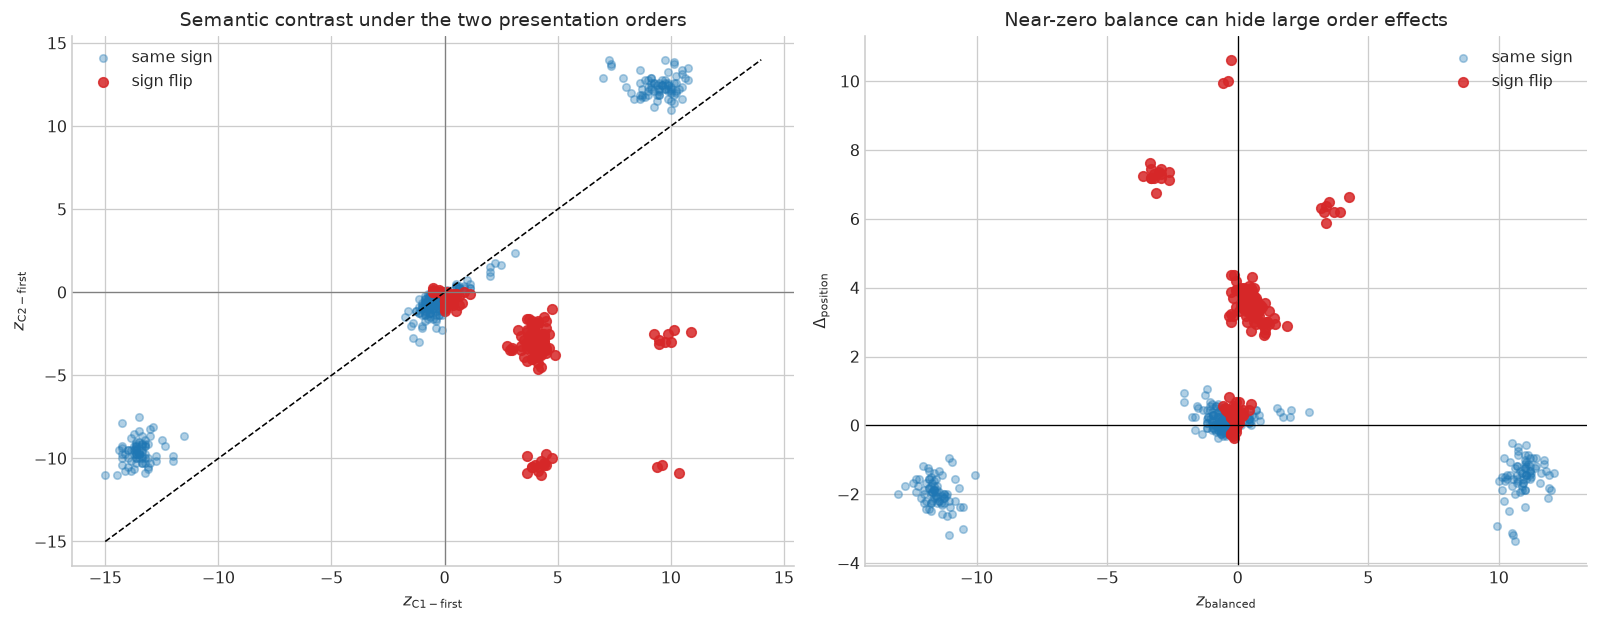

In [21]:
stable = [
    row for row in explorer.balanced_rows
    if row["z_c1_first"] is not None and row["z_c2_first"] is not None and row["q_true"] is not None
]
sign_flips = [row for row in stable if row["logit_sign_flip_after_swap"]]
no_sign_flips = [row for row in stable if not row["logit_sign_flip_after_swap"]]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

axes[0].scatter(
    [row["z_c1_first"] for row in no_sign_flips],
    [row["z_c2_first"] for row in no_sign_flips],
    s=22, alpha=0.35, color="tab:blue", label="same sign",
)
axes[0].scatter(
    [row["z_c1_first"] for row in sign_flips],
    [row["z_c2_first"] for row in sign_flips],
    s=36, alpha=0.85, color="tab:red", label="sign flip",
)
bounds = [
    min(min(row["z_c1_first"], row["z_c2_first"]) for row in stable),
    max(max(row["z_c1_first"], row["z_c2_first"]) for row in stable),
]
axes[0].plot(bounds, bounds, "--", color="black", linewidth=1)
axes[0].axhline(0, color="grey", linewidth=0.8)
axes[0].axvline(0, color="grey", linewidth=0.8)
axes[0].set(
    xlabel=r"$z_{\mathrm{C1-first}}$",
    ylabel=r"$z_{\mathrm{C2-first}}$",
    title="Semantic contrast under the two presentation orders",
)
axes[0].legend()

axes[1].scatter(
    [row["z_balanced"] for row in no_sign_flips],
    [row["delta_position"] for row in no_sign_flips],
    s=22, alpha=0.35, color="tab:blue", label="same sign",
)
axes[1].scatter(
    [row["z_balanced"] for row in sign_flips],
    [row["delta_position"] for row in sign_flips],
    s=36, alpha=0.85, color="tab:red", label="sign flip",
)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set(
    xlabel=r"$z_{\mathrm{balanced}}$",
    ylabel=r"$\Delta_{\mathrm{position}}$",
    title="Near-zero balance can hide large order effects",
)
axes[1].legend()
fig.tight_layout()
plt.show()

## 3. Paired reasoning-on versus reasoning-off

Every point below is already position-balanced and then matched on reliability, question set, and answer pattern. The derived table includes logit change, correctness transition, sign change, confidence amplification, reasoning length, and the change in absolute calibration error.

In [22]:
display(explorer.sql("""
SELECT
    correctness_transition,
    COUNT(*) AS n,
    AVG(z_on_minus_off) AS mean_z_change,
    AVG(confidence_amplification) AS mean_confidence_amplification,
    AVG(change_absolute_calibration_error) AS mean_change_abs_calibration_error,
    AVG(reasoning_length_tokens) AS mean_reasoning_length
FROM reasoning_pairs
GROUP BY correctness_transition
ORDER BY n DESC
"""))

correctness_transition,n,mean_z_change,mean_confidence_amplification,mean_change_abs_calibration_error,mean_reasoning_length
not scored,244,0.579097510373444,0.6496369294605809,0.06538546733087128,796.2397540983607
unchanged right,86,-6.7354651162790695,10.892441860465116,-0.24962594770023702,633.5
wrong→right,70,8.379464285714286,10.35982142857143,-0.5051525205076977,671.2071428571429


In [23]:
def exact_mcnemar_p(wrong_to_right: int, right_to_wrong: int) -> float:
    """Two-sided exact McNemar/binomial test on discordant correctness pairs."""
    discordant = wrong_to_right + right_to_wrong
    if discordant == 0:
        return 1.0
    tail = sum(
        math.comb(discordant, k) * 0.5**discordant
        for k in range(min(wrong_to_right, right_to_wrong) + 1)
    )
    return min(1.0, 2.0 * tail)


def paired_sign_permutation_p(
    differences: list[float], *, resamples: int = 20_000, seed: int = 20260904
) -> float:
    """Two-sided paired sign-permutation test of a zero mean difference."""
    values = [value for value in differences if math.isfinite(value)]
    if not values:
        return math.nan
    observed = abs(fmean(values))
    if len(values) <= 20:
        exceedances = 0
        total = 1 << len(values)
        for mask in range(total):
            statistic = abs(fmean(
                value if mask & (1 << index) else -value
                for index, value in enumerate(values)
            ))
            exceedances += statistic >= observed - 1e-15
        return exceedances / total
    generator = random.Random(seed)
    exceedances = 0
    for _ in range(resamples):
        statistic = abs(fmean(
            value if generator.getrandbits(1) else -value for value in values
        ))
        exceedances += statistic >= observed - 1e-15
    return (exceedances + 1) / (resamples + 1)


paired = [
    row for row in explorer.reasoning_pairs
    if row["z_off"] is not None and row["z_on"] is not None
]
z_changes = [row["z_on_minus_off"] for row in paired]
calibration_changes = [
    row["change_absolute_calibration_error"]
    for row in paired
    if row["change_absolute_calibration_error"] is not None
]
transition_counts = Counter(row["correctness_transition"] for row in paired)
wrong_to_right = transition_counts["wrong→right"]
right_to_wrong = transition_counts["right→wrong"]
sign_change_count = sum(bool(row["choice_sign_flip_reasoning"]) for row in paired)

paired_effect_summary = {
    "matched pairs with both logits": len(paired),
    "paired rows with defined calibration error": len(calibration_changes),
    "mean z_on - z_off": fmean(z_changes),
    "median z_on - z_off": median(z_changes),
    "mean change in absolute calibration error": fmean(calibration_changes),
    "median change in absolute calibration error": median(calibration_changes),
    "wrong→right": wrong_to_right,
    "right→wrong": right_to_wrong,
    "McNemar scored pairs": sum(
        transition_counts[name]
        for name in ("wrong→right", "right→wrong", "unchanged right", "unchanged wrong")
    ),
    "McNemar exact two-sided p": exact_mcnemar_p(wrong_to_right, right_to_wrong),
    "paired sign-permutation p (absolute calibration error)": paired_sign_permutation_p(
        calibration_changes
    ),
    "fraction whose balanced answer sign changes": sign_change_count / len(paired),
}
pprint(paired_effect_summary)

{'McNemar exact two-sided p': 1.6940658945086007e-21,
 'McNemar scored pairs': 156,
 'fraction whose balanced answer sign changes': 0.5239294710327456,
 'matched pairs with both logits': 397,
 'mean change in absolute calibration error': -0.17572475152299613,
 'mean z_on - z_off': 0.36996221662468515,
 'median change in absolute calibration error': -0.16374760689565268,
 'median z_on - z_off': 0.6875,
 'paired rows with defined calibration error': 278,
 'paired sign-permutation p (absolute calibration error)': 4.999750012499375e-05,
 'right→wrong': 0,
 'wrong→right': 70}


### Dumbbells for every matched condition

Each panel contains one reliability and every available question-set/answer-pattern pair. Rows are sorted by their midpoint. Blue circles are reasoning off; orange diamonds are reasoning on. Connecting lines are colored by correctness transition.

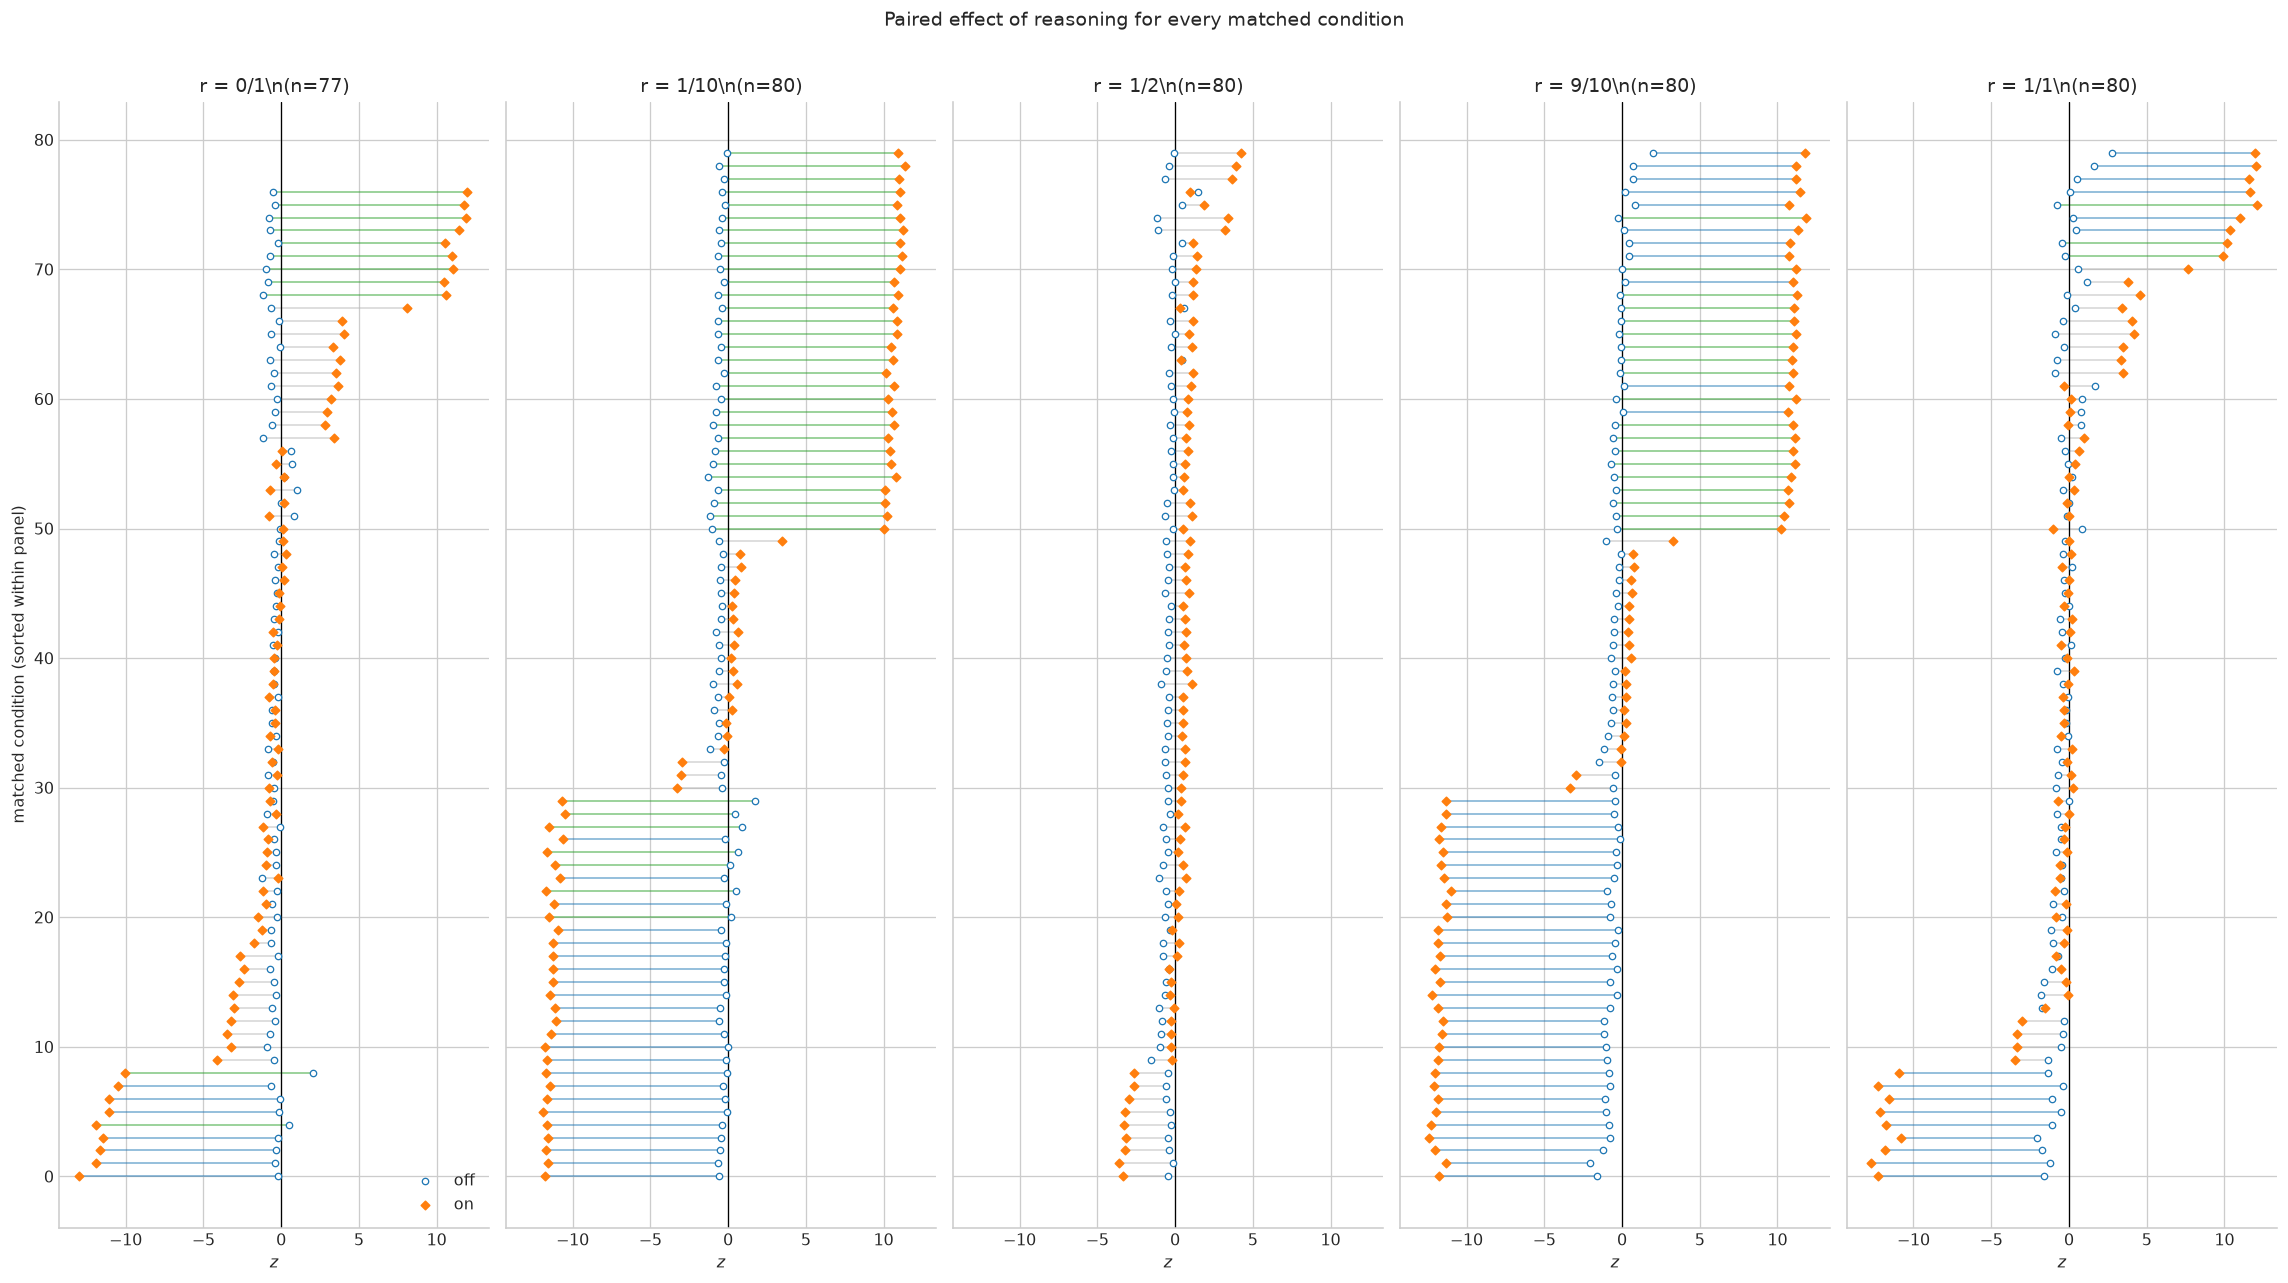

In [24]:
reliability_order = ["0/1", "1/10", "1/2", "9/10", "1/1"]
transition_colors = {
    "wrong→right": "tab:green",
    "right→wrong": "tab:red",
    "unchanged right": "tab:blue",
    "unchanged wrong": "tab:orange",
    "not scored": "0.72",
}

fig, axes = plt.subplots(1, len(reliability_order), figsize=(20, 11), sharex=True, sharey=True)
for axis, reliability_exact in zip(axes, reliability_order, strict=True):
    rows = [row for row in paired if row["reliability_exact"] == reliability_exact]
    rows.sort(key=lambda row: 0.5 * (row["z_off"] + row["z_on"]))
    for y, row in enumerate(rows):
        axis.plot(
            [row["z_off"], row["z_on"]],
            [y, y],
            color=transition_colors[row["correctness_transition"]],
            alpha=0.58,
            linewidth=1.0,
        )
    axis.scatter(
        [row["z_off"] for row in rows],
        range(len(rows)),
        s=16,
        facecolors="white",
        edgecolors="tab:blue",
        linewidths=0.8,
        label="off",
        zorder=3,
    )
    axis.scatter(
        [row["z_on"] for row in rows],
        range(len(rows)),
        s=14,
        color="tab:orange",
        marker="D",
        label="on",
        zorder=3,
    )
    axis.axvline(0, color="black", linewidth=0.8)
    axis.set_title(f"r = {reliability_exact}\\n(n={len(rows)})")
    axis.set_xlabel(r"$z$")
axes[0].set_ylabel("matched condition (sorted within panel)")
axes[0].legend(loc="lower right")
fig.suptitle("Paired effect of reasoning for every matched condition", y=1.01)
fig.tight_layout()
plt.show()

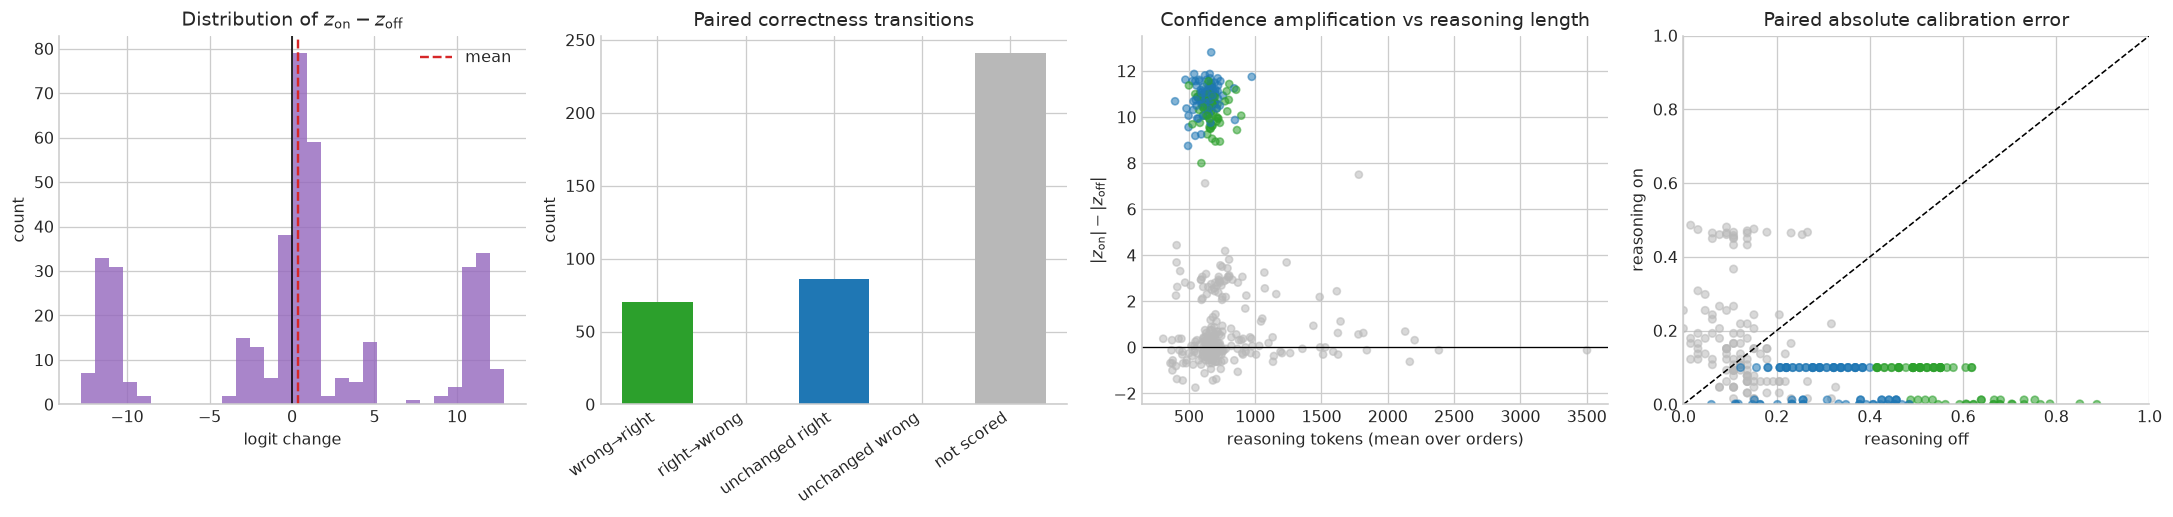

In [25]:
fig, axes = plt.subplots(1, 4, figsize=(19, 4.6))

axes[0].hist(z_changes, bins=30, color="tab:purple", alpha=0.8)
axes[0].axvline(0, color="black", linewidth=1)
axes[0].axvline(fmean(z_changes), color="tab:red", linestyle="--", label="mean")
axes[0].set(title=r"Distribution of $z_{\rm on}-z_{\rm off}$", xlabel="logit change", ylabel="count")
axes[0].legend()

ordered_transitions = [
    "wrong→right", "right→wrong", "unchanged right", "unchanged wrong", "not scored"
]
axes[1].bar(
    range(len(ordered_transitions)),
    [transition_counts[name] for name in ordered_transitions],
    color=[transition_colors[name] for name in ordered_transitions],
)
axes[1].set_xticks(range(len(ordered_transitions)), ordered_transitions, rotation=35, ha="right")
axes[1].set(title="Paired correctness transitions", ylabel="count")

length_rows = [
    row for row in paired
    if row["reasoning_length_tokens"] is not None
    and row["confidence_amplification"] is not None
]
axes[2].scatter(
    [row["reasoning_length_tokens"] for row in length_rows],
    [row["confidence_amplification"] for row in length_rows],
    c=[transition_colors[row["correctness_transition"]] for row in length_rows],
    s=20,
    alpha=0.55,
)
axes[2].axhline(0, color="black", linewidth=0.8)
axes[2].set(
    title="Confidence amplification vs reasoning length",
    xlabel="reasoning tokens (mean over orders)",
    ylabel=r"$|z_{\rm on}|-|z_{\rm off}|$",
)

calibration_pairs = [
    row for row in paired
    if row["absolute_calibration_error_off"] is not None
    and row["absolute_calibration_error_on"] is not None
]
axes[3].scatter(
    [row["absolute_calibration_error_off"] for row in calibration_pairs],
    [row["absolute_calibration_error_on"] for row in calibration_pairs],
    c=[transition_colors[row["correctness_transition"]] for row in calibration_pairs],
    s=22,
    alpha=0.55,
)
axes[3].plot([0, 1], [0, 1], "--", color="black", linewidth=1)
axes[3].set(
    xlim=(0, 1),
    ylim=(0, 1),
    title="Paired absolute calibration error",
    xlabel="reasoning off",
    ylabel="reasoning on",
)
fig.tight_layout()
plt.show()

## 4. Explicit deterministic-endpoint categories

The globally impossible category is assigned first when the full observation evidence is zero. Only among positive-evidence rows do we distinguish one possible candidate, both candidate posteriors zero, or both candidates positive and tied.

Keeping the final category separate is important: this artifact contains one positive/tied row per reasoning setting at each endpoint. Consequently, the directly observed endpoint split is 9 C1-only, 9 C2-only, 41 both-zero, 20 globally impossible, and 1 both-positive/tied—not 42 both-zero. The query and plot below make that audit explicit.

In [26]:
endpoint_counts = explorer.sql("""
SELECT
    reliability_exact,
    reasoning,
    endpoint_category,
    COUNT(*) AS n
FROM balanced_rows
WHERE reliability IN (0.0, 1.0)
GROUP BY reliability_exact, reasoning, endpoint_category
ORDER BY reliability, reasoning, endpoint_category
""")
display(endpoint_counts)

reliability_exact,reasoning,endpoint_category,n
0/1,0,C1 possible and C2 impossible,9
0/1,0,C2 possible and C1 impossible,9
0/1,0,both candidates have zero posterior,41
0/1,0,both candidates positive/tied,1
0/1,0,entire observation pattern has zero evidence,20
0/1,1,C1 possible and C2 impossible,9
0/1,1,C2 possible and C1 impossible,9
0/1,1,both candidates have zero posterior,41
0/1,1,both candidates positive/tied,1
0/1,1,entire observation pattern has zero evidence,20


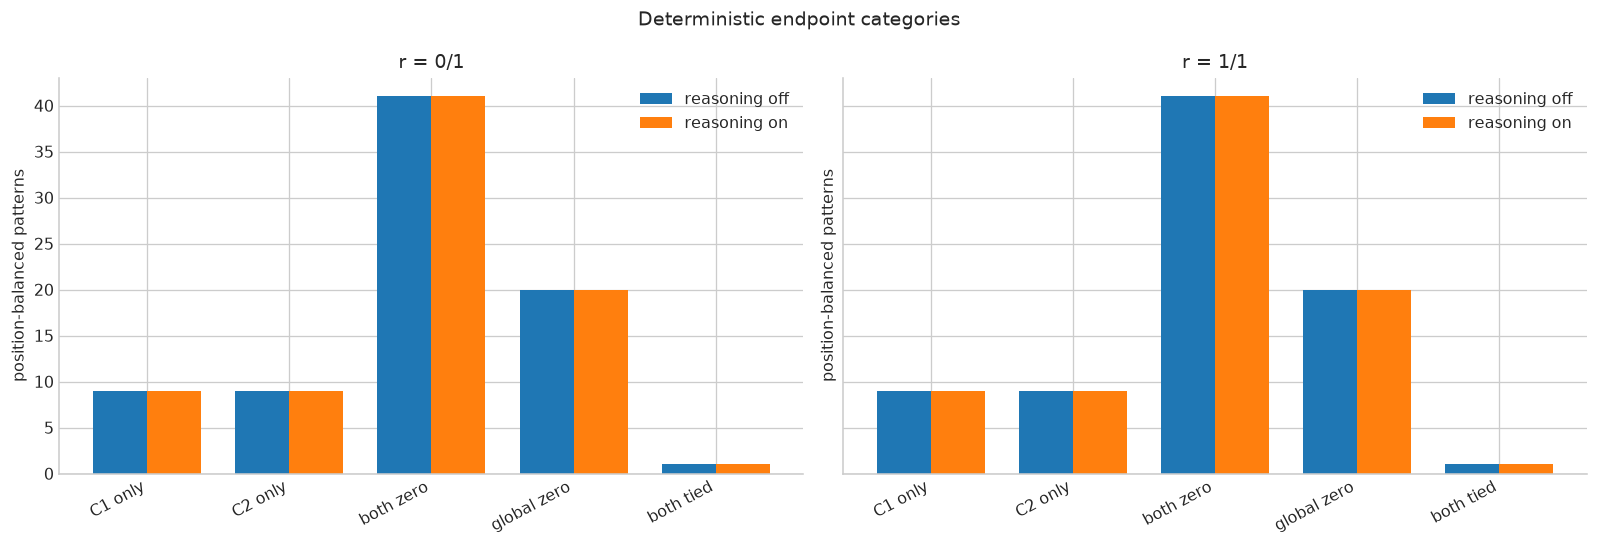

In [27]:
endpoint_categories = [
    "C1 possible and C2 impossible",
    "C2 possible and C1 impossible",
    "both candidates have zero posterior",
    "entire observation pattern has zero evidence",
    "both candidates positive/tied",
]
endpoint_labels = ["C1 only", "C2 only", "both zero", "global zero", "both tied"]
count_lookup = {
    (row["reliability_exact"], bool(row["reasoning"]), row["endpoint_category"]): row["n"]
    for row in endpoint_counts
}

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharey=True)
for axis, reliability_exact in zip(axes, ["0/1", "1/1"], strict=True):
    x = list(range(len(endpoint_categories)))
    width = 0.38
    off = [count_lookup.get((reliability_exact, False, category), 0) for category in endpoint_categories]
    on = [count_lookup.get((reliability_exact, True, category), 0) for category in endpoint_categories]
    axis.bar([value - width / 2 for value in x], off, width, label="reasoning off")
    axis.bar([value + width / 2 for value in x], on, width, label="reasoning on")
    axis.set_xticks(x, endpoint_labels, rotation=28, ha="right")
    axis.set_title(f"r = {reliability_exact}")
    axis.set_ylabel("position-balanced patterns")
    axis.legend()
fig.suptitle("Deterministic endpoint categories")
fig.tight_layout()
plt.show()

## 5. Calibration error, scores, regression, and reliability diagrams

For every position-balanced row with candidate-defined Bayesian mass and both captured logits,

$\[
q_{\mathrm{true}} =
\frac{p(C_1\mid D)}{p(C_1\mid D)+p(C_2\mid D)},
\qquad
q_{\mathrm{LLM}}=\sigma(z_{\mathrm{balanced}}).
\]$

Brier score and soft-label log loss include q_true values of 0 and 1. The requested regression

$\[
z_{\mathrm{LLM}}=\alpha+\beta\,\operatorname{logit}(q_{\mathrm{true}})
\]$

can only use rows with$ 0 < q_{true} < 1$; groups with no variance in true log-odds report undefined slope/intercept. Reliability diagrams bin q_LLM and plot the mean soft target q_true in each occupied bin.

In [28]:
calibration_rows = [
    row for row in explorer.balanced_rows
    if row["q_true"] is not None and row["q_llm"] is not None
]


def ols_calibration(rows: list[dict]) -> tuple[float | None, float | None, int]:
    finite = [
        row for row in rows
        if 0.0 < row["q_true"] < 1.0
        and row["z_balanced"] is not None
    ]
    if not finite:
        return None, None, 0
    x = [math.log(row["q_true"] / (1.0 - row["q_true"])) for row in finite]
    y = [row["z_balanced"] for row in finite]
    mean_x, mean_y = fmean(x), fmean(y)
    denominator = sum((value - mean_x) ** 2 for value in x)
    if math.isclose(denominator, 0.0, abs_tol=1e-15):
        return None, None, len(finite)
    slope = sum((xv - mean_x) * (yv - mean_y) for xv, yv in zip(x, y, strict=True)) / denominator
    intercept = mean_y - slope * mean_x
    return intercept, slope, len(finite)


def summarize_calibration(rows: list[dict], label: str, reasoning: bool) -> dict:
    intercept, slope, regression_n = ols_calibration(rows)
    return {
        "group": label,
        "reasoning": reasoning,
        "n": len(rows),
        "mean_error": fmean(row["calibration_error"] for row in rows),
        "mean_absolute_error": fmean(abs(row["calibration_error"]) for row in rows),
        "brier_score": fmean(row["brier_score"] for row in rows),
        "log_loss": fmean(row["log_loss"] for row in rows),
        "calibration_intercept": intercept,
        "calibration_slope": slope,
        "regression_n": regression_n,
    }


calibration_summaries = []
for reasoning in (False, True):
    selected = [row for row in calibration_rows if bool(row["reasoning"]) is reasoning]
    calibration_summaries.append(summarize_calibration(selected, "pooled", reasoning))
    for reliability_exact in reliability_order:
        group = [row for row in selected if row["reliability_exact"] == reliability_exact]
        calibration_summaries.append(
            summarize_calibration(group, f"r={reliability_exact}", reasoning)
        )

summary_columns = list(calibration_summaries[0])
display(SQLResult(
    summary_columns,
    [[row[column] for column in summary_columns] for row in calibration_summaries],
))

group,reasoning,n,mean_error,mean_absolute_error,brier_score,log_loss,calibration_intercept,calibration_slope,regression_n
pooled,False,278,-0.09595686534732568,0.29125758512499833,0.12424093662621204,0.7232155809429596,-0.4080578512396694,0.02155595824775465,242
r=0/1,False,19,-0.08155889360617702,0.5602790517163904,0.34342591940003653,0.9402222199304778,None,None,1
r=1/10,False,80,-0.09484214118794007,0.3983529176343274,0.1966854428206552,0.8253811715049528,-0.39140625000000007,-0.10222413189656872,80
r=1/2,False,80,-0.09625400531765753,0.11569387482197509,0.017873323721753365,0.7325012866887111,None,None,80
r=9/10,False,80,-0.1006654162637445,0.2887033165391596,0.10399512191109772,0.6238053833339414,-0.42812499999999987,0.14533604839207803,80
r=1/1,False,19,-0.09397181928904252,0.32127884013164026,0.13313562301082887,0.4555095790134349,None,None,1
pooled,True,278,0.031091241683613265,0.11553283360200224,0.02806117373706981,0.7685870886518785,-0.029700413223138832,3.1712814657173594,242
r=0/1,True,19,-0.007212444085113121,0.007226825818379982,0.0009882865686758704,0.0385508516183409,None,None,1
r=1/10,True,80,0.003614311917846909,0.09740519275976951,0.01816540070530294,0.8584545583302303,-0.25312499999999755,3.108280288776754,80
r=1/2,True,80,0.08780315902223364,0.20347782365707684,0.060692803622075,0.921822605372934,None,None,80


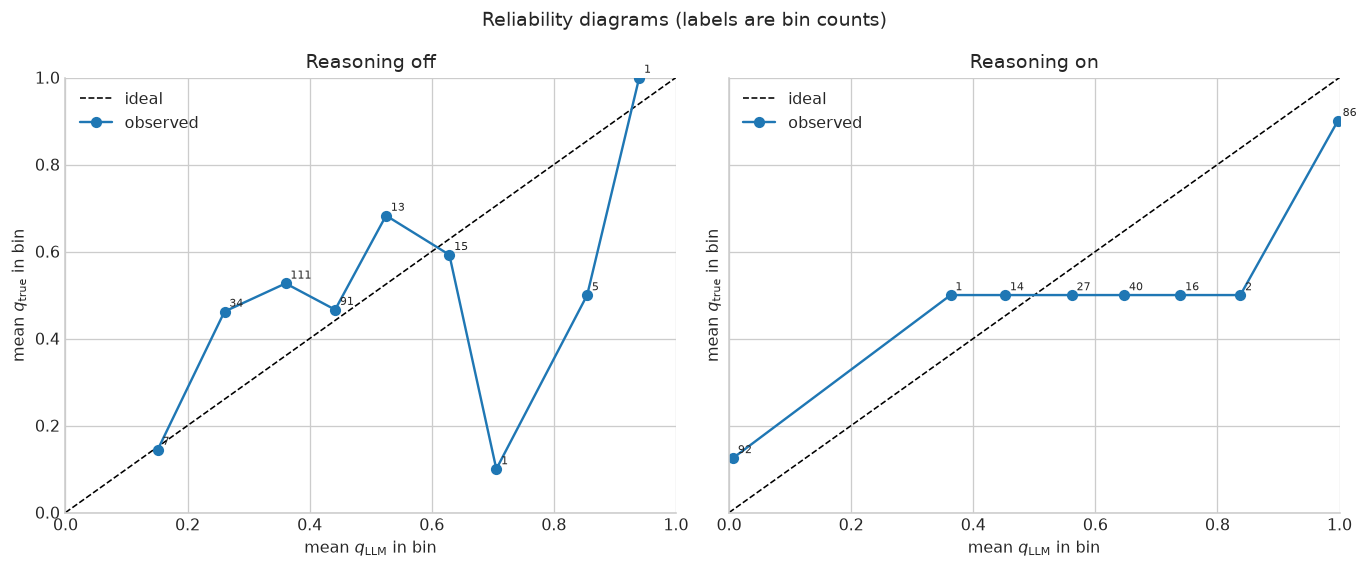

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
bin_count = 10

for axis, reasoning in zip(axes, (False, True), strict=True):
    rows = [row for row in calibration_rows if bool(row["reasoning"]) is reasoning]
    bins = defaultdict(list)
    for row in rows:
        index = min(int(row["q_llm"] * bin_count), bin_count - 1)
        bins[index].append(row)
    predicted_means = [fmean(row["q_llm"] for row in bins[index]) for index in sorted(bins)]
    target_means = [fmean(row["q_true"] for row in bins[index]) for index in sorted(bins)]
    counts = [len(bins[index]) for index in sorted(bins)]
    axis.plot([0, 1], [0, 1], "--", color="black", linewidth=1, label="ideal")
    axis.plot(predicted_means, target_means, "o-", color="tab:blue", label="observed")
    for x_value, y_value, count in zip(predicted_means, target_means, counts, strict=True):
        axis.annotate(str(count), (x_value, y_value), xytext=(3, 3), textcoords="offset points", fontsize=7)
    axis.set(
        xlim=(0, 1),
        ylim=(0, 1),
        xlabel=r"mean $q_{\mathrm{LLM}}$ in bin",
        ylabel=r"mean $q_{\mathrm{true}}$ in bin",
        title=f"Reasoning {'on' if reasoning else 'off'}",
    )
    axis.legend()
fig.suptitle("Reliability diagrams (labels are bin counts)")
fig.tight_layout()
plt.show()

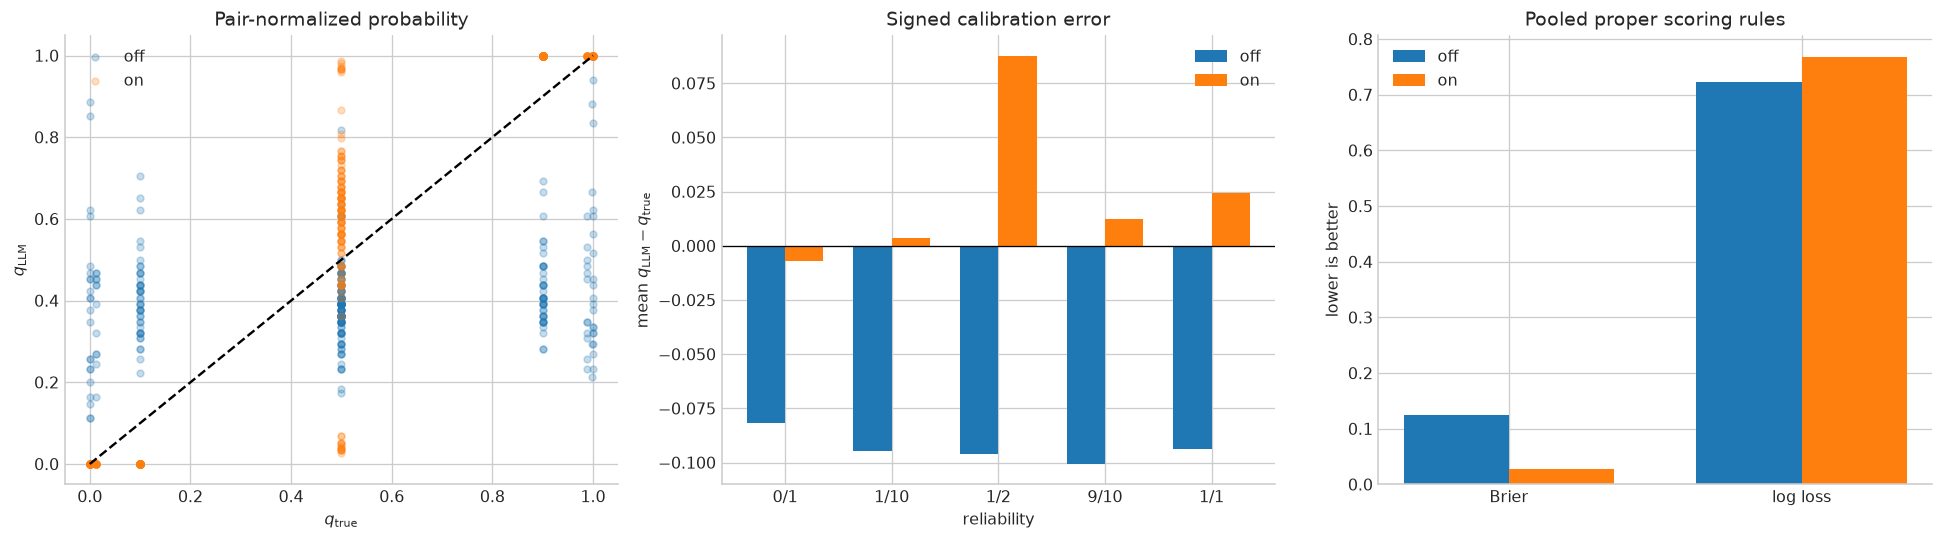

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))

for reasoning, color, label in [(False, "tab:blue", "off"), (True, "tab:orange", "on")]:
    rows = [row for row in calibration_rows if bool(row["reasoning"]) is reasoning]
    axes[0].scatter(
        [row["q_true"] for row in rows],
        [row["q_llm"] for row in rows],
        s=18,
        alpha=0.25,
        color=color,
        label=label,
    )
axes[0].plot([0, 1], [0, 1], "--", color="black")
axes[0].set(
    xlabel=r"$q_{\mathrm{true}}$",
    ylabel=r"$q_{\mathrm{LLM}}$",
    title="Pair-normalized probability",
)
axes[0].legend()

for reasoning, color, label in [(False, "tab:blue", "off"), (True, "tab:orange", "on")]:
    means = []
    for reliability_exact in reliability_order:
        rows = [
            row for row in calibration_rows
            if bool(row["reasoning"]) is reasoning
            and row["reliability_exact"] == reliability_exact
        ]
        means.append(fmean(row["calibration_error"] for row in rows))
    offset = -0.18 if not reasoning else 0.18
    axes[1].bar(
        [index + offset for index in range(len(reliability_order))],
        means,
        0.36,
        color=color,
        label=label,
    )
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_xticks(range(len(reliability_order)), reliability_order)
axes[1].set(
    xlabel="reliability",
    ylabel=r"mean $q_{\mathrm{LLM}}-q_{\mathrm{true}}$",
    title="Signed calibration error",
)
axes[1].legend()

metric_names = ["brier_score", "log_loss"]
x = list(range(len(metric_names)))
width = 0.36
for reasoning, color, label, offset in [
    (False, "tab:blue", "off", -width / 2),
    (True, "tab:orange", "on", width / 2),
]:
    pooled = next(
        row for row in calibration_summaries
        if row["group"] == "pooled" and bool(row["reasoning"]) is reasoning
    )
    axes[2].bar(
        [value + offset for value in x],
        [pooled[name] for name in metric_names],
        width,
        color=color,
        label=label,
    )
axes[2].set_xticks(x, ["Brier", "log loss"])
axes[2].set(title="Pooled proper scoring rules", ylabel="lower is better")
axes[2].legend()

fig.tight_layout()
plt.show()

## Further exploration recipes

The objects below are ordinary Python dictionaries as well as SQL rows. Useful variations include filtering one question set, changing the “likely incorrect” threshold, grouping position flips by reliability/reasoning, and opening the exact source transcript for any row ID.

In [31]:
# Questions whose candidate ordering most often changes the actual emitted answer.
display(explorer.sql("""
SELECT
    question_set_index,
    reliability_exact,
    reasoning,
    COUNT(*) AS n,
    SUM(semantic_choice_flip_after_swap) AS emitted_choice_flips,
    SUM(logit_sign_flip_after_swap) AS logit_sign_flips,
    AVG(ABS(delta_position)) AS mean_abs_position_effect
FROM balanced_rows
WHERE pair_has_answer_boundary_logits = 1
GROUP BY question_set_index, reliability_exact, reasoning
HAVING COUNT(*) >= 5
ORDER BY emitted_choice_flips DESC, mean_abs_position_effect DESC
LIMIT 30
"""))

# A narrow condition query; edit the values or selected columns freely.
display(
    explorer.query("balanced_rows")
    .select(
        "question_set_index",
        "answer_pattern",
        "question_subsets_json",
        "observed_reports_json",
        "candidate_1_posterior",
        "candidate_2_posterior",
        "z_balanced",
        "delta_position",
    )
    .where_eq(reliability_exact="9/10", reasoning=True)
    .where("question_set_index IN (?, ?)", 0, 1)
    .sort("question_set_index", "answer_pattern_index")
    .run()
)

question_set_index,reliability_exact,reasoning,n,emitted_choice_flips,logit_sign_flips,mean_abs_position_effect
5,0/1,1,8,8,8,9.1484375
5,1/1,1,8,8,8,7.734375
0,1/2,1,8,8,8,5.2578125
5,1/2,1,8,8,8,4.7578125
1,1/2,1,8,8,8,4.546875
8,1/2,1,8,8,8,4.484375
3,1/2,1,8,8,8,4.46875
9,1/2,1,8,8,8,4.4375
5,1/10,1,8,8,8,4.40625
7,1/2,1,8,8,8,3.859375


question_set_index,answer_pattern,question_subsets_json,observed_reports_json,candidate_1_posterior,candidate_2_posterior,z_balanced,delta_position
0,YYY,"[[3,5,6,8],[1,5,7,8],[1,4,5,6]]","[""YES"",""YES"",""YES""]",0.001,0.009,-11.8125,-1.5625
0,YYN,"[[3,5,6,8],[1,5,7,8],[1,4,5,6]]","[""YES"",""YES"",""NO""]",0.009,0.081,-12.4375,-1.6875
0,YNY,"[[3,5,6,8],[1,5,7,8],[1,4,5,6]]","[""YES"",""NO"",""YES""]",0.009,0.001,11.0,-1.125
0,YNN,"[[3,5,6,8],[1,5,7,8],[1,4,5,6]]","[""YES"",""NO"",""NO""]",0.081,0.009,10.75,-0.75
0,NYY,"[[3,5,6,8],[1,5,7,8],[1,4,5,6]]","[""NO"",""YES"",""YES""]",0.009,0.081,-12.3125,-1.5625
0,NYN,"[[3,5,6,8],[1,5,7,8],[1,4,5,6]]","[""NO"",""YES"",""NO""]",0.081,0.729,-11.8125,-1.3125
0,NNY,"[[3,5,6,8],[1,5,7,8],[1,4,5,6]]","[""NO"",""NO"",""YES""]",0.081,0.009,11.25,-1.375
0,NNN,"[[3,5,6,8],[1,5,7,8],[1,4,5,6]]","[""NO"",""NO"",""NO""]",0.729,0.081,11.0,-0.875
1,YYY,"[[4,6,7,8],[2,4,5,8],[1,3,5,6]]","[""YES"",""YES"",""YES""]",0.025,0.025,-0.0625,4.1875
1,YYN,"[[4,6,7,8],[2,4,5,8],[1,3,5,6]]","[""YES"",""YES"",""NO""]",0.04939024390243903,0.04939024390243903,-0.0625,3.9375
